In [1]:
# Kaggle original datasets: https://www.kaggle.com/datasets/thedevastator/airbnb-prices-in-european-cities/
# Futher documentation on original datasets: https://zenodo.org/records/4446043

In [2]:
!pip install pandas

In [3]:
import numpy as np

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, classification_report, confusion_matrix, f1_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor,AdaBoostRegressor, GradientBoostingRegressor
from sklearn.utils import resample
from sklearn.tree import export_text
from sklearn.tree import DecisionTreeRegressor, export_graphviz
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
import pickle

In [5]:
pip install graphviz

Note: you may need to restart the kernel to use updated packages.


In [6]:
import graphviz

In [7]:
# Set naming conventions for the 20 different datasets
# wd: weekdays
# we: weekends

# ams: Amsterdam
# ath: Athens
# bcn: Barcelona
# ber: Berlin
# bud: Budapest
# lis: Lisbon
# lon: London
# par: Paris
# rom: Rome
# vie: Vienna

In [8]:
# Create df for berlin districts
df_districts_europe = pd.read_excel(r"C:\Users\aican\2025-Ironhack\GitHub\Unit8-2025-CW-23\Airbnb-Prices-in-European-Cities\airbnb-with-districts-new-xlsx.xlsx")

In [9]:
df_districts_europe

,Unnamed: 0,realSum,room_type,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,...,weekends,city,geometry,index_right,gml_id,Gemeinde_name,Gemeinde_schluessel,Land_name,Land_schluessel,Schluessel_gesamt
0,0,194.033698,Private room,0,1,2,0,1,0,10,...,0,Amsterdam,POINT (4.90569 52.41772),NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,344.245776,Private room,0,1,4,0,0,0,8,...,0,Amsterdam,POINT (4.90005 52.37432),NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,264.101422,Private room,0,1,2,0,0,1,9,...,0,Amsterdam,POINT (4.97512 52.36103),NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,433.529398,Private room,0,1,4,0,0,1,9,...,0,Amsterdam,POINT (4.89417 52.37663),NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,485.552926,Private room,0,1,2,1,0,0,10,...,0,Amsterdam,POINT (4.90051 52.37508),NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48976,51696,359.021107,Private room,0,1,5,0,0,1,10,...,1,Vienna,POINT (16.36758 48.21567),NaN,NaN,NaN,NaN,NaN,NaN,NaN
48977,51700,115.933899,Private room,0,1,4,0,1,0,9,...,1,Vienna,POINT (16.3397 48.19325),NaN,NaN,NaN,NaN,NaN,NaN,NaN
48978,51703,304.793960,Entire home/apt,0,0,2,0,0,0,8,...,1,Vienna,POINT (16.3807 48.20296),NaN,NaN,NaN,NaN,NaN,NaN,NaN
48979,51705,301.054157,Private room,0,1,2,0,0,0,10,...,1,Vienna,POINT (16.341 48.192),NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# Filter rows where city is exactly "Berlin"
df_berlin_only = df_districts_europe[df_districts_europe["city"] == "Berlin"]

In [11]:
df_berlin_only

,Unnamed: 0,realSum,room_type,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,...,weekends,city,geometry,index_right,gml_id,Gemeinde_name,Gemeinde_schluessel,Land_name,Land_schluessel,Schluessel_gesamt
9566,10193,185.799757,Private room,0,1,2,1,0,0,10,...,0,Berlin,POINT (13.42344 52.4915),4.0,s_wfs_alkis_bezirk.F176__5,Neuk��lln,8.0,Berlin,11.0,11000008.0
9567,10194,194.914462,Private room,0,1,5,0,0,1,9,...,0,Berlin,POINT (13.468 52.519),10.0,s_wfs_alkis_bezirk.F176__11,Friedrichshain-Kreuzberg,2.0,Berlin,11.0,11000002.0
9568,10195,176.217631,Private room,0,1,2,0,0,0,9,...,0,Berlin,POINT (13.47096 52.51527),10.0,s_wfs_alkis_bezirk.F176__11,Friedrichshain-Kreuzberg,2.0,Berlin,11.0,11000002.0
9569,10196,207.768533,Private room,0,1,3,1,0,0,10,...,0,Berlin,POINT (13.42281 52.53139),3.0,s_wfs_alkis_bezirk.F176__4,Pankow,3.0,Berlin,11.0,11000003.0
9570,10197,150.743199,Private room,0,1,2,0,0,0,10,...,0,Berlin,POINT (13.5244 52.47841999999999),5.0,s_wfs_alkis_bezirk.F176__6,Lichtenberg,11.0,Berlin,11.0,11000011.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11880,12672,84.836870,Private room,0,1,2,0,0,0,10,...,1,Berlin,POINT (13.549 52.4),2.0,s_wfs_alkis_bezirk.F176__3,Treptow-K��penick,9.0,Berlin,11.0,11000009.0
11881,12673,134.617182,Private room,0,1,4,0,1,0,10,...,1,Berlin,POINT (13.53187 52.40874),2.0,s_wfs_alkis_bezirk.F176__3,Treptow-K��penick,9.0,Berlin,11.0,11000009.0
11882,12674,134.617182,Private room,0,1,4,0,1,0,10,...,1,Berlin,POINT (13.53301 52.40712),2.0,s_wfs_alkis_bezirk.F176__3,Treptow-K��penick,9.0,Berlin,11.0,11000009.0
11883,12675,160.091614,Entire home/apt,0,0,3,0,0,0,9,...,1,Berlin,POINT (13.70702 52.42405),2.0,s_wfs_alkis_bezirk.F176__3,Treptow-K��penick,9.0,Berlin,11.0,11000009.0


In [12]:
# Show unique district names in Berlin
print(df_berlin_only["Gemeinde_name"].unique())

['Neuk��lln' 'Friedrichshain-Kreuzberg' 'Pankow' 'Lichtenberg'
 'Charlottenburg-Wilmersdorf' 'Treptow-K��penick' 'Steglitz-Zehlendorf'
 'Mitte' 'Tempelhof-Sch��neberg' 'Spandau' 'Marzahn-Hellersdorf'
 'Reinickendorf']


In [13]:
# Correct misspelled district names in 'Gemeinde_name'
df_berlin_only["Gemeinde_name"] = df_berlin_only["Gemeinde_name"].replace({
    "Neuk��lln": "Neukölln",
    "Tempelhof-Sch��neberg": "Tempelhof-Schöneberg",
    "Treptow-K��penick": "Treptow-Köpenick"
})

C:\Users\aican\AppData\Local\Temp\ipykernel_21076\2917582217.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_berlin_only["Gemeinde_name"] = df_berlin_only["Gemeinde_name"].replace({


In [14]:
# Show unique district names in Berlin
print(df_berlin_only["Gemeinde_name"].unique())

['Neukölln' 'Friedrichshain-Kreuzberg' 'Pankow' 'Lichtenberg'
 'Charlottenburg-Wilmersdorf' 'Treptow-Köpenick' 'Steglitz-Zehlendorf'
 'Mitte' 'Tempelhof-Schöneberg' 'Spandau' 'Marzahn-Hellersdorf'
 'Reinickendorf']


In [15]:
# Drop unnecessary columns
df_berlin_only = df_berlin_only.drop(columns=[
    "geometry", 
    "index_right", 
    "gml_id", 
    "Gemeinde_schluessel", 
    "Land_name", 
    "Land_schluessel", 
    "Schluessel_gesamt"
])

In [16]:
df_berlin_only

,Unnamed: 0,realSum,room_type,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,...,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,lng,lat,weekends,city,Gemeinde_name
9566,10193,185.799757,Private room,0,1,2,1,0,0,10,...,0.174706,105.063708,16.019042,148.941114,30.710638,13.42344,52.49150,0,Berlin,Neukölln
9567,10194,194.914462,Private room,0,1,5,0,0,1,9,...,0.511922,75.339529,11.487002,106.442356,21.947685,13.46800,52.51900,0,Berlin,Friedrichshain-Kreuzberg
9568,10195,176.217631,Private room,0,1,2,0,0,0,9,...,0.281397,73.669176,11.232324,105.440205,21.741048,13.47096,52.51527,0,Berlin,Friedrichshain-Kreuzberg
9569,10196,207.768533,Private room,0,1,3,1,0,0,10,...,0.705573,133.187409,20.307057,198.233362,40.874362,13.42281,52.53139,0,Berlin,Pankow
9570,10197,150.743199,Private room,0,1,2,0,0,0,10,...,2.187188,39.860151,6.077469,50.996308,10.515090,13.52440,52.47842,0,Berlin,Lichtenberg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11880,12672,84.836870,Private room,0,1,2,0,0,0,10,...,4.070691,23.484663,3.579546,30.663099,6.487380,13.54900,52.40000,1,Berlin,Treptow-Köpenick
11881,12673,134.617182,Private room,0,1,4,0,1,0,10,...,2.620839,25.750931,3.924972,33.433648,7.073544,13.53187,52.40874,1,Berlin,Treptow-Köpenick
11882,12674,134.617182,Private room,0,1,4,0,1,0,10,...,2.754838,25.439079,3.877440,33.027106,6.987532,13.53301,52.40712,1,Berlin,Treptow-Köpenick
11883,12675,160.091614,Entire home/apt,0,0,3,0,0,0,9,...,13.314115,16.600731,2.530293,21.455797,4.539394,13.70702,52.42405,1,Berlin,Treptow-Köpenick


In [17]:
# We are using both weekdays and weekends in Berlin.

In [18]:
# Use get_dummies function to perform one-hot encoding (convert categorical variables into multiple binary columns).
df_berlin_only_dummies = pd.get_dummies(df_berlin_only[["room_type", "city", "Gemeinde_name"]])

In [19]:
df_berlin_only_dummies

,room_type_Entire home/apt,room_type_Private room,room_type_Shared room,city_Berlin,Gemeinde_name_Charlottenburg-Wilmersdorf,Gemeinde_name_Friedrichshain-Kreuzberg,Gemeinde_name_Lichtenberg,Gemeinde_name_Marzahn-Hellersdorf,Gemeinde_name_Mitte,Gemeinde_name_Neukölln,Gemeinde_name_Pankow,Gemeinde_name_Reinickendorf,Gemeinde_name_Spandau,Gemeinde_name_Steglitz-Zehlendorf,Gemeinde_name_Tempelhof-Schöneberg,Gemeinde_name_Treptow-Köpenick
9566,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,False
9567,False,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False
9568,False,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False
9569,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,False
9570,False,True,False,True,False,False,True,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11880,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,True
11881,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,True
11882,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,True
11883,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True


In [20]:
# Drop "unnamed" column
df_berlin_only = df_berlin_only.drop(columns=['Unnamed: 0'])

In [21]:
numeric_cols = df_berlin_only.select_dtypes(include=['number'])

In [22]:
numeric_cols.head(5)

,realSum,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,lng,lat,weekends
9566,185.799757,0,1,2,1,0,0,10,98,1,3.582211,0.174706,105.063708,16.019042,148.941114,30.710638,13.42344,52.49150,0
9567,194.914462,0,1,5,0,0,1,9,86,1,3.525410,0.511922,75.339529,11.487002,106.442356,21.947685,13.46800,52.51900,0
9568,176.217631,0,1,2,0,0,0,9,91,1,3.801713,0.281397,73.669176,11.232324,105.440205,21.741048,13.47096,52.51527,0
9569,207.768533,0,1,3,1,0,0,10,97,1,0.982408,0.705573,133.187409,20.307057,198.233362,40.874362,13.42281,52.53139,0
9570,150.743199,0,1,2,0,0,0,10,99,1,8.869697,2.187188,39.860151,6.077469,50.996308,10.515090,13.52440,52.47842,0


In [23]:
# We won't drop the columns latitude and longitude.

In [24]:
# Concatenate features (dfs "numeric_cols" and "df_berlin_only_dummies")
features = pd.concat([numeric_cols, df_berlin_only_dummies], axis=1)

In [25]:
features.drop(columns = ["realSum"], inplace=True)

In [26]:
features.columns

Index(['room_shared', 'room_private', 'person_capacity', 'host_is_superhost',
       'multi', 'biz', 'cleanliness_rating', 'guest_satisfaction_overall',
       'bedrooms', 'dist', 'metro_dist', 'attr_index', 'attr_index_norm',
       'rest_index', 'rest_index_norm', 'lng', 'lat', 'weekends',
       'room_type_Entire home/apt', 'room_type_Private room',
       'room_type_Shared room', 'city_Berlin',
       'Gemeinde_name_Charlottenburg-Wilmersdorf',
       'Gemeinde_name_Friedrichshain-Kreuzberg', 'Gemeinde_name_Lichtenberg',
       'Gemeinde_name_Marzahn-Hellersdorf', 'Gemeinde_name_Mitte',
       'Gemeinde_name_Neukölln', 'Gemeinde_name_Pankow',
       'Gemeinde_name_Reinickendorf', 'Gemeinde_name_Spandau',
       'Gemeinde_name_Steglitz-Zehlendorf',
       'Gemeinde_name_Tempelhof-Schöneberg', 'Gemeinde_name_Treptow-Köpenick'],
      dtype='object')

In [27]:
features.columns

Index(['room_shared', 'room_private', 'person_capacity', 'host_is_superhost',
       'multi', 'biz', 'cleanliness_rating', 'guest_satisfaction_overall',
       'bedrooms', 'dist', 'metro_dist', 'attr_index', 'attr_index_norm',
       'rest_index', 'rest_index_norm', 'lng', 'lat', 'weekends',
       'room_type_Entire home/apt', 'room_type_Private room',
       'room_type_Shared room', 'city_Berlin',
       'Gemeinde_name_Charlottenburg-Wilmersdorf',
       'Gemeinde_name_Friedrichshain-Kreuzberg', 'Gemeinde_name_Lichtenberg',
       'Gemeinde_name_Marzahn-Hellersdorf', 'Gemeinde_name_Mitte',
       'Gemeinde_name_Neukölln', 'Gemeinde_name_Pankow',
       'Gemeinde_name_Reinickendorf', 'Gemeinde_name_Spandau',
       'Gemeinde_name_Steglitz-Zehlendorf',
       'Gemeinde_name_Tempelhof-Schöneberg', 'Gemeinde_name_Treptow-Köpenick'],
      dtype='object')

In [28]:
target = df_berlin_only["realSum"]

In [29]:
target

9566     185.799757
9567     194.914462
9568     176.217631
9569     207.768533
9570     150.743199
            ...    
11880     84.836870
11881    134.617182
11882    134.617182
11883    160.091614
11884    359.680284
Name: realSum, Length: 2319, dtype: float64

In [30]:
df_berlin_only.head(5)

,realSum,room_type,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,...,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,lng,lat,weekends,city,Gemeinde_name
9566,185.799757,Private room,0,1,2,1,0,0,10,98,...,0.174706,105.063708,16.019042,148.941114,30.710638,13.42344,52.49150,0,Berlin,Neukölln
9567,194.914462,Private room,0,1,5,0,0,1,9,86,...,0.511922,75.339529,11.487002,106.442356,21.947685,13.46800,52.51900,0,Berlin,Friedrichshain-Kreuzberg
9568,176.217631,Private room,0,1,2,0,0,0,9,91,...,0.281397,73.669176,11.232324,105.440205,21.741048,13.47096,52.51527,0,Berlin,Friedrichshain-Kreuzberg
9569,207.768533,Private room,0,1,3,1,0,0,10,97,...,0.705573,133.187409,20.307057,198.233362,40.874362,13.42281,52.53139,0,Berlin,Pankow
9570,150.743199,Private room,0,1,2,0,0,0,10,99,...,2.187188,39.860151,6.077469,50.996308,10.515090,13.52440,52.47842,0,Berlin,Lichtenberg


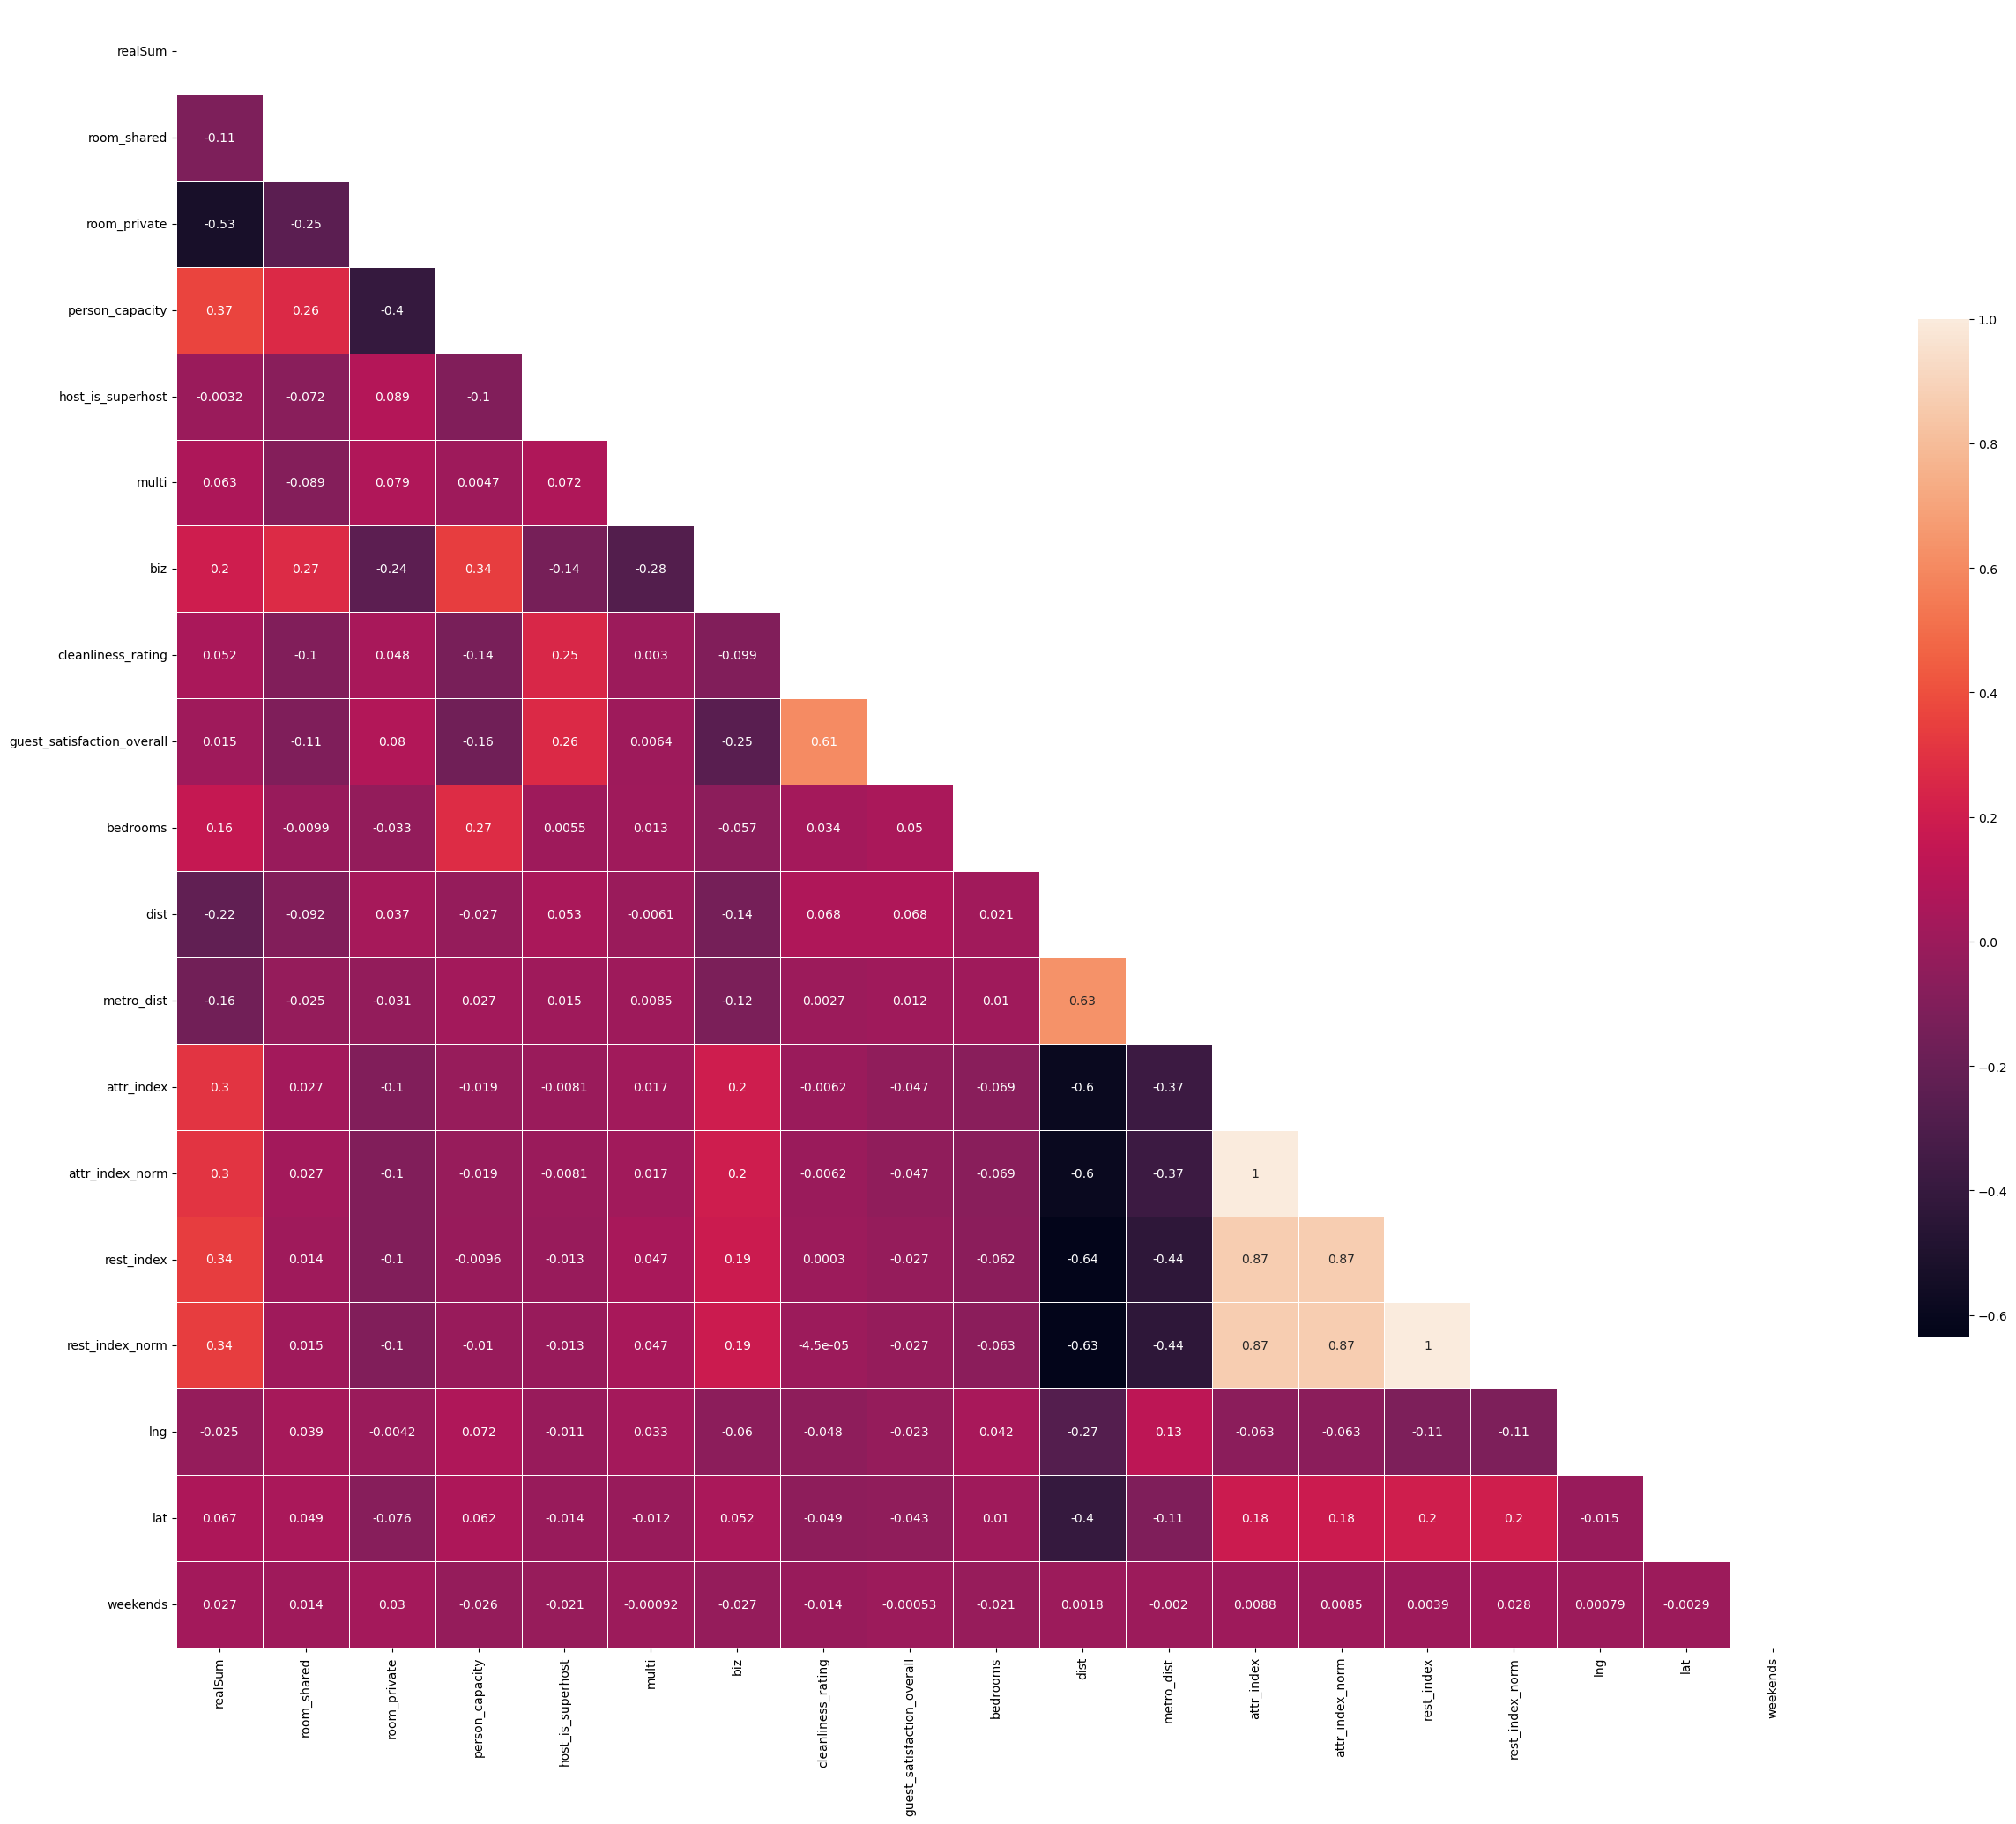

In [31]:
corr=np.abs(numeric_cols).corr()

#Set up mask for triangle representation
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(30, 30))
# Generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)
# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask,  vmax=1,square=True, linewidths=.5, cbar_kws={"shrink": .5},annot = corr)

plt.show()

In [32]:
# Compute absolute correlations
corr_values = numeric_cols.corr()['realSum'].abs().sort_values(ascending=False)

# Print correlation values
print(corr_values)

realSum                       1.000000
room_private                  0.528694
person_capacity               0.365699
rest_index_norm               0.341637
rest_index                    0.341106
attr_index                    0.304844
attr_index_norm               0.304838
dist                          0.224217
biz                           0.200716
bedrooms                      0.158828
metro_dist                    0.157579
room_shared                   0.112981
lat                           0.066887
multi                         0.062797
cleanliness_rating            0.051574
weekends                      0.027212
lng                           0.024590
guest_satisfaction_overall    0.014983
host_is_superhost             0.003226
Name: realSum, dtype: float64


In [33]:
# Choice between StandardScaler and MinMaxScaler
# We will use MinMaxScaler, because it doesn't assume normality, so it works well with skewed or not normal distributions.
# It rescales values between O and 1 without changing the overall distribution pattern.

In [34]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.20, random_state=42)

In [35]:
X_train.head()

,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,...,Gemeinde_name_Lichtenberg,Gemeinde_name_Marzahn-Hellersdorf,Gemeinde_name_Mitte,Gemeinde_name_Neukölln,Gemeinde_name_Pankow,Gemeinde_name_Reinickendorf,Gemeinde_name_Spandau,Gemeinde_name_Steglitz-Zehlendorf,Gemeinde_name_Tempelhof-Schöneberg,Gemeinde_name_Treptow-Köpenick
11256,0,1,2,0,0,0,6,90,0,8.223368,...,False,False,False,False,False,False,False,False,False,True
11395,0,1,2,0,0,0,8,100,1,3.835243,...,False,False,False,False,True,False,False,False,False,False
11644,0,0,3,0,0,0,10,100,0,0.756135,...,False,False,True,False,False,False,False,False,False,False
10741,0,1,2,0,0,0,10,100,1,8.059328,...,False,False,False,False,False,False,False,False,True,False
11766,0,0,3,0,0,0,10,100,1,10.802629,...,False,False,False,True,False,False,False,False,False,False


In [36]:
normalizer = MinMaxScaler()

In [37]:
normalizer.fit(X_train)

MinMaxScaler()

In [38]:
X_train_norm = normalizer.transform(X_train)

X_test_norm = normalizer.transform(X_test)

In [39]:
X_train.head(5)

,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,...,Gemeinde_name_Lichtenberg,Gemeinde_name_Marzahn-Hellersdorf,Gemeinde_name_Mitte,Gemeinde_name_Neukölln,Gemeinde_name_Pankow,Gemeinde_name_Reinickendorf,Gemeinde_name_Spandau,Gemeinde_name_Steglitz-Zehlendorf,Gemeinde_name_Tempelhof-Schöneberg,Gemeinde_name_Treptow-Köpenick
11256,0,1,2,0,0,0,6,90,0,8.223368,...,False,False,False,False,False,False,False,False,False,True
11395,0,1,2,0,0,0,8,100,1,3.835243,...,False,False,False,False,True,False,False,False,False,False
11644,0,0,3,0,0,0,10,100,0,0.756135,...,False,False,True,False,False,False,False,False,False,False
10741,0,1,2,0,0,0,10,100,1,8.059328,...,False,False,False,False,False,False,False,False,True,False
11766,0,0,3,0,0,0,10,100,1,10.802629,...,False,False,False,True,False,False,False,False,False,False


In [40]:
X_train_norm

array([[0.  , 1.  , 0.  , ..., 0.  , 0.  , 1.  ],
       [0.  , 1.  , 0.  , ..., 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.25, ..., 0.  , 0.  , 0.  ],
       ...,
       [0.  , 0.  , 0.25, ..., 0.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  , ..., 0.  , 0.  , 0.  ],
       [0.  , 1.  , 0.25, ..., 0.  , 0.  , 0.  ]])

In [41]:
X_train.describe()

,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,lng,lat,weekends
count,1855.000000,1855.000000,1855.000000,1855.000000,1855.00000,1855.000000,1855.000000,1855.000000,1855.000000,1855.000000,1855.000000,1855.000000,1855.000000,1855.000000,1855.000000,1855.000000,1855.000000,1855.000000
mean,0.035040,0.648518,2.683558,0.260377,0.27062,0.169272,9.448518,94.301348,1.027493,5.431747,0.883872,105.068851,16.017318,140.674980,29.371805,13.401928,52.508203,0.484636
std,0.183932,0.477562,1.094570,0.438959,0.44440,0.375093,0.853584,6.598541,0.507547,3.761285,1.355293,66.336286,10.112638,75.724281,15.814421,0.073524,0.034702,0.499899
min,0.000000,0.000000,2.000000,0.000000,0.00000,0.000000,4.000000,40.000000,0.000000,0.180926,0.011382,15.152201,2.309508,19.576924,4.141882,13.116320,52.370000,0.000000
25%,0.000000,0.000000,2.000000,0.000000,0.00000,0.000000,9.000000,92.000000,1.000000,2.955305,0.281442,66.357671,10.115903,90.596165,18.799562,13.358580,52.489770,0.000000
50%,0.000000,1.000000,2.000000,0.000000,0.00000,0.000000,10.000000,96.000000,1.000000,4.496715,0.458447,89.422404,13.629908,127.381174,26.640231,13.409000,52.508350,0.000000
75%,0.000000,1.000000,3.000000,1.000000,1.00000,0.000000,10.000000,99.000000,1.000000,6.827095,0.855705,125.284040,19.098963,178.243269,37.161670,13.443150,52.529800,1.000000
max,1.000000,1.000000,6.000000,1.000000,1.00000,1.000000,10.000000,100.000000,9.000000,25.284557,14.273577,656.079318,100.000000,472.716923,100.000000,13.711850,52.641410,1.000000


In [42]:
# Convert NumPy array to DataFrame
X_train_norm_df = pd.DataFrame(X_train_norm)

In [43]:
X_train.describe()

,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,lng,lat,weekends
count,1855.000000,1855.000000,1855.000000,1855.000000,1855.00000,1855.000000,1855.000000,1855.000000,1855.000000,1855.000000,1855.000000,1855.000000,1855.000000,1855.000000,1855.000000,1855.000000,1855.000000,1855.000000
mean,0.035040,0.648518,2.683558,0.260377,0.27062,0.169272,9.448518,94.301348,1.027493,5.431747,0.883872,105.068851,16.017318,140.674980,29.371805,13.401928,52.508203,0.484636
std,0.183932,0.477562,1.094570,0.438959,0.44440,0.375093,0.853584,6.598541,0.507547,3.761285,1.355293,66.336286,10.112638,75.724281,15.814421,0.073524,0.034702,0.499899
min,0.000000,0.000000,2.000000,0.000000,0.00000,0.000000,4.000000,40.000000,0.000000,0.180926,0.011382,15.152201,2.309508,19.576924,4.141882,13.116320,52.370000,0.000000
25%,0.000000,0.000000,2.000000,0.000000,0.00000,0.000000,9.000000,92.000000,1.000000,2.955305,0.281442,66.357671,10.115903,90.596165,18.799562,13.358580,52.489770,0.000000
50%,0.000000,1.000000,2.000000,0.000000,0.00000,0.000000,10.000000,96.000000,1.000000,4.496715,0.458447,89.422404,13.629908,127.381174,26.640231,13.409000,52.508350,0.000000
75%,0.000000,1.000000,3.000000,1.000000,1.00000,0.000000,10.000000,99.000000,1.000000,6.827095,0.855705,125.284040,19.098963,178.243269,37.161670,13.443150,52.529800,1.000000
max,1.000000,1.000000,6.000000,1.000000,1.00000,1.000000,10.000000,100.000000,9.000000,25.284557,14.273577,656.079318,100.000000,472.716923,100.000000,13.711850,52.641410,1.000000


In [44]:
X_train_norm = pd.DataFrame(X_train_norm, columns = X_train.columns)
X_train_norm.head()

,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,...,Gemeinde_name_Lichtenberg,Gemeinde_name_Marzahn-Hellersdorf,Gemeinde_name_Mitte,Gemeinde_name_Neukölln,Gemeinde_name_Pankow,Gemeinde_name_Reinickendorf,Gemeinde_name_Spandau,Gemeinde_name_Steglitz-Zehlendorf,Gemeinde_name_Tempelhof-Schöneberg,Gemeinde_name_Treptow-Köpenick
0,0.0,1.0,0.00,0.0,0.0,0.0,0.333333,0.833333,0.000000,0.320370,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,1.0,0.00,0.0,0.0,0.0,0.666667,1.000000,0.111111,0.145569,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.25,0.0,0.0,0.0,1.000000,1.000000,0.000000,0.022913,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,1.0,0.00,0.0,0.0,0.0,1.000000,1.000000,0.111111,0.313835,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.25,0.0,0.0,0.0,1.000000,1.000000,0.111111,0.423114,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [45]:
X_test_norm = pd.DataFrame(X_test_norm, columns = X_test.columns)
X_test_norm.head()

,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,...,Gemeinde_name_Lichtenberg,Gemeinde_name_Marzahn-Hellersdorf,Gemeinde_name_Mitte,Gemeinde_name_Neukölln,Gemeinde_name_Pankow,Gemeinde_name_Reinickendorf,Gemeinde_name_Spandau,Gemeinde_name_Steglitz-Zehlendorf,Gemeinde_name_Tempelhof-Schöneberg,Gemeinde_name_Treptow-Köpenick
0,0.0,1.0,0.5,1.0,0.0,0.0,1.000000,0.950000,0.111111,0.797711,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,1.0,0.5,0.0,0.0,0.0,1.000000,0.900000,0.111111,0.116645,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,1.000000,0.950000,0.111111,0.219299,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,1.0,0.833333,0.866667,0.000000,0.094307,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,1.000000,1.000000,0.111111,0.268469,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [46]:
knn = KNeighborsRegressor()

In [47]:
knn

KNeighborsRegressor()

In [48]:
knn.fit(X_train_norm, y_train)

KNeighborsRegressor()

In [49]:
# Evaluate the model's performance: KNN

In [50]:
accuracy = knn.score(X_test_norm, y_test)

C:\Users\aican\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\aican\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\aican\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\aican\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\aican\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

In [51]:
accuracy

0.4671001508910626

In [52]:
# Conclusions:
# 0.702988339452034: The model explains 70.30 % of the variance in y_test based on the features in X_test_norm.
# The model fits the data well because the value is close to 1, meaning predictions are highly accurate.

In [53]:
# Make predictions for KNN model
pred_knn = knn.predict(X_test_norm) # Here I need X_test_norm, not X_test.
pred_knn

array([125.22202487, 189.1651865 , 186.68785641, 277.22725998,
       126.3905768 , 266.28961391, 151.25736188, 215.20052351,
       227.72740021, 156.91315322, 146.77012246, 163.12984949,
       165.09301673, 260.07291764, 222.95970833, 197.71898663,
       165.42021127, 164.15817519, 381.08815556, 153.31401327,
       237.73020473, 232.77554455, 236.70187903, 191.96971113,
       242.63812284, 218.75292138, 206.92717584, 185.98672525,
       307.23567355, 351.36019445, 217.95830607, 256.24006731,
       200.38328503, 262.87744227, 301.43965598, 152.14546134,
       152.75310835, 169.95419276, 204.82378237, 195.24165654,
       136.34663924, 177.24595681, 208.75011686, 158.17518931,
       319.94951856, 183.27568477, 168.92586707, 145.50808638,
       363.93381322, 149.5746471 , 164.29840142, 147.23754324,
       225.20332804, 145.83528092, 261.52192203, 231.98092923,
       355.28652893, 213.42432458, 266.66355053, 320.37019725,
       268.766944  , 150.55623072, 199.02776479, 353.22

In [54]:
Y_pred = knn.predict(X_test)

In [55]:
Y_pred

array([299.38300458, 312.42404412, 371.08535103, 312.42404412,
       371.08535103, 371.08535103, 371.08535103, 353.69729831,
       312.42404412, 371.08535103, 371.08535103, 371.08535103,
       312.42404412, 371.08535103, 312.42404412, 312.42404412,
       371.08535103, 371.08535103, 371.08535103, 371.08535103,
       371.08535103, 312.42404412, 371.08535103, 368.74824717,
       312.42404412, 312.42404412, 312.42404412, 371.08535103,
       312.42404412, 312.42404412, 371.08535103, 312.42404412,
       371.08535103, 312.42404412, 371.08535103, 371.08535103,
       371.08535103, 371.08535103, 312.42404412, 312.42404412,
       371.08535103, 329.34467608, 312.42404412, 371.08535103,
       371.08535103, 312.42404412, 312.42404412, 371.08535103,
       371.08535103, 371.08535103, 371.08535103, 312.42404412,
       312.42404412, 312.42404412, 312.42404412, 327.00757222,
       342.10526316, 312.42404412, 371.08535103, 371.08535103,
       371.08535103, 371.08535103, 341.404132  , 312.42

In [56]:
y_true = y_test

In [57]:
# Calculate metrics  
print("MAE (KNN):", mean_absolute_error(y_test, pred_knn))  
print("RMSE (KNN):", mean_squared_error(y_test, pred_knn, squared=False))  
print("R2 score (KNN):", r2_score(y_test, pred_knn))

MAE (KNN): 47.78218917324548
RMSE (KNN): 64.30405427575016
R2 score (KNN): 0.4671001508910626


C:\Users\aican\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [58]:
X_test_norm.head(5)

,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,...,Gemeinde_name_Lichtenberg,Gemeinde_name_Marzahn-Hellersdorf,Gemeinde_name_Mitte,Gemeinde_name_Neukölln,Gemeinde_name_Pankow,Gemeinde_name_Reinickendorf,Gemeinde_name_Spandau,Gemeinde_name_Steglitz-Zehlendorf,Gemeinde_name_Tempelhof-Schöneberg,Gemeinde_name_Treptow-Köpenick
0,0.0,1.0,0.5,1.0,0.0,0.0,1.000000,0.950000,0.111111,0.797711,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,1.0,0.5,0.0,0.0,0.0,1.000000,0.900000,0.111111,0.116645,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,1.000000,0.950000,0.111111,0.219299,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,1.0,0.833333,0.866667,0.000000,0.094307,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,1.000000,1.000000,0.111111,0.268469,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [59]:
y_test.head(5)

10691    185.566047
10114    139.057680
9666     125.035057
10404    278.115359
9817     122.931663
Name: realSum, dtype: float64

In [60]:
y_test.values

array([185.56604656, 139.05767972, 125.03505656, 278.11535945,
       122.93166308, 150.74319903, 162.42871833, 162.42871833,
       287.69748528,  64.97148733, 139.29139011, 140.22623165,
       185.56604656, 263.15789474, 258.24997663, 150.74319903,
       197.25156586, 177.38618304, 401.28073292, 231.840703  ,
       192.57735814, 334.90698327, 324.62372628, 376.97485276,
       321.11807049, 129.94297467, 169.44002991, 142.7970459 ,
       475.60063569, 359.68028419, 132.04636814, 285.36038142,
       115.9203515 , 408.05833411, 139.29139011, 125.03505656,
       301.72010844, 133.21492007, 204.26287744, 160.09161447,
       173.88052725,  91.61447135, 150.74319903, 162.19500795,
       290.03458914, 148.40609517, 162.42871833, 103.06628027,
       327.19454053, 136.72057586, 162.42871833, 129.94297467,
       168.27147798, 136.95428625, 288.63232682, 122.93166308,
       382.58390203, 220.1551837 , 301.48639806, 234.17780686,
       353.83752454, 127.6058708 , 220.1551837 , 333.97

In [61]:
# Use Random Forest, Decision Tree and Linear Regression

In [62]:
# Linear Regression

In [63]:
features.head(5)

,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,...,Gemeinde_name_Lichtenberg,Gemeinde_name_Marzahn-Hellersdorf,Gemeinde_name_Mitte,Gemeinde_name_Neukölln,Gemeinde_name_Pankow,Gemeinde_name_Reinickendorf,Gemeinde_name_Spandau,Gemeinde_name_Steglitz-Zehlendorf,Gemeinde_name_Tempelhof-Schöneberg,Gemeinde_name_Treptow-Köpenick
9566,0,1,2,1,0,0,10,98,1,3.582211,...,False,False,False,True,False,False,False,False,False,False
9567,0,1,5,0,0,1,9,86,1,3.525410,...,False,False,False,False,False,False,False,False,False,False
9568,0,1,2,0,0,0,9,91,1,3.801713,...,False,False,False,False,False,False,False,False,False,False
9569,0,1,3,1,0,0,10,97,1,0.982408,...,False,False,False,False,True,False,False,False,False,False
9570,0,1,2,0,0,0,10,99,1,8.869697,...,True,False,False,False,False,False,False,False,False,False


In [64]:
target.head(5)

9566    185.799757
9567    194.914462
9568    176.217631
9569    207.768533
9570    150.743199
Name: realSum, dtype: float64

In [65]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.20, random_state=42)

In [66]:
normalizer = MinMaxScaler()

normalizer.fit(X_train)

MinMaxScaler()

In [67]:
X_train_norm = normalizer.transform(X_train)

X_test_norm = normalizer.transform(X_test)

In [68]:
X_train_norm = pd.DataFrame(X_train_norm, columns = X_train.columns)
X_train_norm.head()

,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,...,Gemeinde_name_Lichtenberg,Gemeinde_name_Marzahn-Hellersdorf,Gemeinde_name_Mitte,Gemeinde_name_Neukölln,Gemeinde_name_Pankow,Gemeinde_name_Reinickendorf,Gemeinde_name_Spandau,Gemeinde_name_Steglitz-Zehlendorf,Gemeinde_name_Tempelhof-Schöneberg,Gemeinde_name_Treptow-Köpenick
0,0.0,1.0,0.00,0.0,0.0,0.0,0.333333,0.833333,0.000000,0.320370,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,1.0,0.00,0.0,0.0,0.0,0.666667,1.000000,0.111111,0.145569,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.25,0.0,0.0,0.0,1.000000,1.000000,0.000000,0.022913,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,1.0,0.00,0.0,0.0,0.0,1.000000,1.000000,0.111111,0.313835,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.25,0.0,0.0,0.0,1.000000,1.000000,0.111111,0.423114,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [69]:
X_test_norm = pd.DataFrame(X_test_norm, columns = X_test.columns)
X_test_norm.head()

,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,...,Gemeinde_name_Lichtenberg,Gemeinde_name_Marzahn-Hellersdorf,Gemeinde_name_Mitte,Gemeinde_name_Neukölln,Gemeinde_name_Pankow,Gemeinde_name_Reinickendorf,Gemeinde_name_Spandau,Gemeinde_name_Steglitz-Zehlendorf,Gemeinde_name_Tempelhof-Schöneberg,Gemeinde_name_Treptow-Köpenick
0,0.0,1.0,0.5,1.0,0.0,0.0,1.000000,0.950000,0.111111,0.797711,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,1.0,0.5,0.0,0.0,0.0,1.000000,0.900000,0.111111,0.116645,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,1.000000,0.950000,0.111111,0.219299,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,1.0,0.833333,0.866667,0.000000,0.094307,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,1.000000,1.000000,0.111111,0.268469,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [70]:
lin_reg = LinearRegression()

In [71]:
# Training Linear Regression with our normalized data
lin_reg.fit(X_train_norm, y_train)

LinearRegression()

In [72]:
# Evaluate model's performance

In [73]:
pred = lin_reg.predict(X_test_norm)

print("MAE Linear Regression", mean_absolute_error(pred, y_test))
print("RMSE Linear Regression", mean_squared_error(pred, y_test, squared=False))
print("R2 score Linear Regression", lin_reg.score(X_test_norm, y_test))

MAE Linear Regression 45.18012293040387
RMSE Linear Regression 59.88617485570167
R2 score Linear Regression 0.5378084146094702


C:\Users\aican\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [74]:
y_test

10691    185.566047
10114    139.057680
9666     125.035057
10404    278.115359
9817     122.931663
            ...    
10669    109.142750
11783    193.979620
11059    254.978031
11091    455.735253
11020    165.700664
Name: realSum, Length: 464, dtype: float64

In [75]:
y_train

11256     95.120127
11395    156.585959
11644    324.390016
10741     93.951575
11766    208.703375
            ...    
11204    280.919884
10661    333.972142
10696    201.692063
10860    324.623726
10426    194.680752
Name: realSum, Length: 1855, dtype: float64

In [76]:
# Decision Tree

In [77]:
# Initialize a Decision Tree instance
tree = DecisionTreeRegressor(max_depth=20)

In [78]:
tree.fit(X_train_norm, y_train)

DecisionTreeRegressor(max_depth=20)

In [79]:
X_train_norm

,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,...,Gemeinde_name_Lichtenberg,Gemeinde_name_Marzahn-Hellersdorf,Gemeinde_name_Mitte,Gemeinde_name_Neukölln,Gemeinde_name_Pankow,Gemeinde_name_Reinickendorf,Gemeinde_name_Spandau,Gemeinde_name_Steglitz-Zehlendorf,Gemeinde_name_Tempelhof-Schöneberg,Gemeinde_name_Treptow-Köpenick
0,0.0,1.0,0.00,0.0,0.0,0.0,0.333333,0.833333,0.000000,0.320370,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,1.0,0.00,0.0,0.0,0.0,0.666667,1.000000,0.111111,0.145569,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.25,0.0,0.0,0.0,1.000000,1.000000,0.000000,0.022913,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,1.0,0.00,0.0,0.0,0.0,1.000000,1.000000,0.111111,0.313835,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.25,0.0,0.0,0.0,1.000000,1.000000,0.111111,0.423114,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1850,0.0,0.0,0.00,0.0,0.0,0.0,1.000000,1.000000,0.111111,0.200846,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1851,0.0,0.0,0.75,0.0,0.0,0.0,0.500000,0.666667,0.222222,0.120217,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1852,0.0,0.0,0.25,0.0,0.0,0.0,1.000000,0.866667,0.111111,0.825147,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1853,0.0,1.0,0.00,1.0,1.0,0.0,1.000000,0.966667,0.111111,0.091452,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [80]:
y_test

10691    185.566047
10114    139.057680
9666     125.035057
10404    278.115359
9817     122.931663
            ...    
10669    109.142750
11783    193.979620
11059    254.978031
11091    455.735253
11020    165.700664
Name: realSum, Length: 464, dtype: float64

In [81]:
pred = tree.predict(X_test_norm)

print("MAE Decision Tree", mean_absolute_error(pred, y_test))
print("RMSE Decision Tree", mean_squared_error(pred, y_test, squared=False))
print("R2 score Decision Tree", tree.score(X_test_norm, y_test))

MAE Decision Tree 30.482430392914623
RMSE Decision Tree 54.37442529527419
R2 score Decision Tree 0.6189708113654802


C:\Users\aican\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [82]:
# Conclusions:
# Mean Absolute Error (MAE = 89.33). On average, my predictions are off by about 89.33 units from the actual values.

In [83]:
print(pd.Series(y_test).describe())

count    464.000000
mean     210.681854
std       88.182834
min       64.971487
25%      144.608301
50%      183.228943
75%      266.955689
max      475.600636
Name: realSum, dtype: float64


In [84]:
# we check what are the most relevant features.

In [85]:
tree_importance = {feature : importance for feature, importance in zip(X_train_norm.columns, tree.feature_importances_)}
tree_importance           

{'room_shared': 0.0010375703369097493,
 'room_private': 0.0014513598752883868,
 'person_capacity': 0.06509578944117267,
 'host_is_superhost': 0.010998224884284159,
 'multi': 0.009313509141236192,
 'biz': 0.01769594849108647,
 'cleanliness_rating': 0.013683681022175787,
 'guest_satisfaction_overall': 0.03907280593767375,
 'bedrooms': 0.014158421780883789,
 'dist': 0.054962233331253725,
 'metro_dist': 0.11433338137343704,
 'attr_index': 0.03386881023597309,
 'attr_index_norm': 0.027395399522471837,
 'rest_index': 0.059610636977457394,
 'rest_index_norm': 0.06800817878118569,
 'lng': 0.04811559874282209,
 'lat': 0.05864235842754876,
 'weekends': 0.005844683377209476,
 'room_type_Entire home/apt': 0.3311564681587904,
 'room_type_Private room': 0.00021025286643159462,
 'room_type_Shared room': 0.0,
 'city_Berlin': 0.0,
 'Gemeinde_name_Charlottenburg-Wilmersdorf': 0.00026095180082636685,
 'Gemeinde_name_Friedrichshain-Kreuzberg': 0.0007105718100071274,
 'Gemeinde_name_Lichtenberg': 0.0001400

In [86]:
# later, don't drop:
#latitude and longitude 
# find the districts for every city
# gfind dataset

# NOT DONE

In [87]:
# Random Forest

In [88]:
# Initialize a Random Forest

In [89]:
forest = RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42)

In [90]:
forest.fit(X_train_norm, y_train)

RandomForestRegressor(max_depth=20, random_state=42)

In [91]:
pred = forest.predict(X_test_norm)

print("MAE Random Forest", mean_absolute_error(pred, y_test))
print("RMSE Random Forest", mean_squared_error(pred, y_test, squared=False))
print("R2 score Random Forest", forest.score(X_test_norm, y_test))

MAE Random Forest 30.462867642753995
RMSE Random Forest 43.75943445780889
R2 score Random Forest 0.7532186773097218


C:\Users\aican\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [92]:
# MAE (KNN): 47.78218917324548
# RMSE (KNN): 64.30405427575016
# R2 score (KNN): 0.4671001508910626

# MAE Linear Regression 45.18012293040387
# RMSE Linear Regression 59.88617485570167
# R2 score Linear Regression 0.5378084146094702

# MAE Decision Tree 30.697112234791938
# RMSE Decision Tree 56.828953018823064
# R2 score Decision Tree 0.5837941344995738

# MAE Random Forest 30.462867642753995
# RMSE Random Forest 43.75943445780889
# R2 score Random Forest 0.7532186773097218

# Conclusions:
# Random Forest performed the best overall. 
# Lowest Error Metrics, MAE (30.46) & RMSE (43.76) among all models, meaning Random Forest has the most accurate predictions on average.
# R2 Score (0.75) explains 75 % of the variance in y_test. This is the highest R2 score, so Random Forest captures more patterns in the data.

In [93]:
# Hyperparameter Tuning of Random Forest using Grid Search

In [94]:
# Define hyperparameter grid
grid = {
    'max_depth': [10, 20, 30, None],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10],
    'n_estimators': [50, 100, 200, 500]
}

In [95]:
# min samples lieaf is 1 and min samples split is 2 have null values by default (not given) 100 estim, depth 20

In [96]:
# If it keeps not running, drop min_samples_leaf 1 and 2, as well as n_estimators 500.

In [97]:
# Initialize Random Forest
forest = RandomForestRegressor()

In [98]:
# Perform Grid Search
model = GridSearchCV(estimator=forest, param_grid=grid, cv=5, n_jobs=-1)

In [99]:
model.fit(X_train_norm, y_train)

C:\Users\aican\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


GridSearchCV(cv=5, estimator=RandomForestRegressor(), n_jobs=-1,
             param_grid={'max_depth': [10, 20, 30, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200, 500]})

In [100]:
# Print Grid Search results

In [101]:
print("Best parameters:", model.best_params_)
print("Best R² Score:", model.best_score_)

Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best R² Score: 0.6708502063497708


In [102]:
# Train final model with best parameters
best_forest = RandomForestRegressor(**model.best_params_)
best_forest.fit(X_train_norm, y_train)

RandomForestRegressor(n_estimators=200)

In [103]:
# Print final model score
print("Final Random Forest R² Score:", best_forest.score(X_test_norm, y_test))

Final Random Forest R² Score: 0.7514313381139082


In [104]:
# max leaf also use
# max_depth': 20 10 5
# max leaf nodes
# minimum sample split: 

In [105]:
# Best parameters: {'max_depth': 20, 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 200}
# Best R² Score: 0.7980558092956832
# Final Random Forest R² Score: 0.8179046171922822

In [106]:
# After performing grid search for Random Forest, we conlude that the parameters given by default (for min_samples_leaf 1 and for min_samples_split 2),
# together with the set parameters of (max_depth=20, random_state=42) before the Hyperparameter Tuning of Random Forest using Grid Search, delivered the highest R2 score.

# The the Hyperparameter Tuning of Random Forest using Grid Search was done with all combinations of the following parameters:
# grid = {'max_depth': [10, 20],
# 'min_samples_leaf': [4],
# 'min_samples_split': [2, 5, 10],
# 'n_estimators': [50, 100, 200]}
# The best parameters from grid search were found to be:  {'max_depth': 20, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}.
# In the case of min_samples_split, 2 is the best parameter and also the default used before grid search.

In [107]:
import pickle

In [108]:
# Save the model to a pickle file
with open('knn.pkl', 'wb') as file:
    pickle.dump(knn, file)

In [109]:
# Load the model back later
with open('knn.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

# Example use:
predictions = loaded_model.predict(X_test)

In [110]:
# Here are the results for the variable "Y_pred" in our previous line of code above.
predictions

array([299.38300458, 312.42404412, 371.08535103, 312.42404412,
       371.08535103, 371.08535103, 371.08535103, 353.69729831,
       312.42404412, 371.08535103, 371.08535103, 371.08535103,
       312.42404412, 371.08535103, 312.42404412, 312.42404412,
       371.08535103, 371.08535103, 371.08535103, 371.08535103,
       371.08535103, 312.42404412, 371.08535103, 368.74824717,
       312.42404412, 312.42404412, 312.42404412, 371.08535103,
       312.42404412, 312.42404412, 371.08535103, 312.42404412,
       371.08535103, 312.42404412, 371.08535103, 371.08535103,
       371.08535103, 371.08535103, 312.42404412, 312.42404412,
       371.08535103, 329.34467608, 312.42404412, 371.08535103,
       371.08535103, 312.42404412, 312.42404412, 371.08535103,
       371.08535103, 371.08535103, 371.08535103, 312.42404412,
       312.42404412, 312.42404412, 312.42404412, 327.00757222,
       342.10526316, 312.42404412, 371.08535103, 371.08535103,
       371.08535103, 371.08535103, 341.404132  , 312.42

In [111]:
# Use a pickle file for linear regression.

In [112]:
# Save the trained model
with open('lin_reg.pkl', 'wb') as file:
    pickle.dump(lin_reg, file)

In [113]:
# Load the previously saved model
with open('lin_reg.pkl', 'rb') as file:
    lin_reg = pickle.load(file)

# Use the loaded model with already existing test data
pred = lin_reg.predict(X_test_norm)

# Evaluate performance again (optional)
print("MAE Linear Regression", mean_absolute_error(pred, y_test))
print("RMSE Linear Regression", mean_squared_error(pred, y_test, squared=False))
print("R2 score Linear Regression", lin_reg.score(X_test_norm, y_test))

MAE Linear Regression 45.18012293040387
RMSE Linear Regression 59.88617485570167
R2 score Linear Regression 0.5378084146094702


C:\Users\aican\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [114]:
# Save both model and normalizer
with open('linreg_with_scaler.pkl', 'wb') as file:
    pickle.dump((normalizer, lin_reg), file)

In [115]:
# Use a pickle file for decision tree.

In [116]:
# Save the trained Decision Tree model
with open('tree.pkl', 'wb') as file:
    pickle.dump(tree, file)

In [117]:
# Load the Decision Tree model
with open('tree.pkl', 'rb') as file:
    tree = pickle.load(file)

# Predict and evaluate using the already existing test data
pred = tree.predict(X_test_norm)

print("MAE Decision Tree", mean_absolute_error(pred, y_test))
print("RMSE Decision Tree", mean_squared_error(pred, y_test, squared=False))
print("R2 score Decision Tree", tree.score(X_test_norm, y_test))

MAE Decision Tree 30.482430392914623
RMSE Decision Tree 54.37442529527419
R2 score Decision Tree 0.6189708113654802


C:\Users\aican\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [118]:
# Feature importances
tree_importance = {feature: importance for feature, importance in zip(X_train_norm.columns, tree.feature_importances_)}
print(tree_importance)

# Tree visualization
from sklearn.tree import export_text
tree_viz = export_text(tree, feature_names=list(X_train_norm.columns))
print(tree_viz)

{'room_shared': 0.0010375703369097493, 'room_private': 0.0014513598752883868, 'person_capacity': 0.06509578944117267, 'host_is_superhost': 0.010998224884284159, 'multi': 0.009313509141236192, 'biz': 0.01769594849108647, 'cleanliness_rating': 0.013683681022175787, 'guest_satisfaction_overall': 0.03907280593767375, 'bedrooms': 0.014158421780883789, 'dist': 0.054962233331253725, 'metro_dist': 0.11433338137343704, 'attr_index': 0.03386881023597309, 'attr_index_norm': 0.027395399522471837, 'rest_index': 0.059610636977457394, 'rest_index_norm': 0.06800817878118569, 'lng': 0.04811559874282209, 'lat': 0.05864235842754876, 'weekends': 0.005844683377209476, 'room_type_Entire home/apt': 0.3311564681587904, 'room_type_Private room': 0.00021025286643159462, 'room_type_Shared room': 0.0, 'city_Berlin': 0.0, 'Gemeinde_name_Charlottenburg-Wilmersdorf': 0.00026095180082636685, 'Gemeinde_name_Friedrichshain-Kreuzberg': 0.0007105718100071274, 'Gemeinde_name_Lichtenberg': 0.0001400452897539331, 'Gemeinde_

In [119]:
# Save the basic Random Forest model
with open('random_forest_model.pkl', 'wb') as file:
    pickle.dump(forest, file)

In [121]:
# Retrain and Save the Fitted Model
from sklearn.ensemble import RandomForestRegressor
import pickle

# Train the model (must be done BEFORE saving!)
forest = RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42)
forest.fit(X_train_norm, y_train)

# Save the trained model
with open('forest.pkl', 'wb') as file:
    pickle.dump(forest, file)

In [123]:
# Load and Predict

# Load the trained model
with open('forest.pkl', 'rb') as file:
    forest = pickle.load(file)

# Predict and evaluate
pred = forest.predict(X_test_norm)
print("MAE Random Forest", mean_absolute_error(pred, y_test))
print("RMSE Random Forest", mean_squared_error(pred, y_test, squared=False))
print("R2 score Random Forest", forest.score(X_test_norm, y_test))

MAE Random Forest 30.462867642753995
RMSE Random Forest 43.75943445780889
R2 score Random Forest 0.7532186773097218


C:\Users\aican\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [125]:
# Save the GridSearchCV object
with open('random_forest_gridsearch.pkl', 'wb') as file:
    pickle.dump(model, file)

In [127]:
# Load the GridSearchCV object
with open('random_forest_gridsearch.pkl', 'rb') as file:
    model = pickle.load(file)

# Best model after reloading
best_forest = model.best_estimator_

# Evaluate using the same test set
pred = best_forest.predict(X_test_norm)
print("MAE GridSearch RF", mean_absolute_error(pred, y_test))
print("RMSE GridSearch RF", mean_squared_error(pred, y_test, squared=False))
print("R2 GridSearch RF", best_forest.score(X_test_norm, y_test))

MAE GridSearch RF 30.62654228707373
RMSE GridSearch RF 43.97700740897418
R2 GridSearch RF 0.7507585713861633


C:\Users\aican\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
